In [1]:
import math
from builtins import range, print
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
class Grayscale_transformation:
    def __init__(self,image=None):
        self.rgb_img = image
        self.image = None
        
    def reverse(self):
        new_image = 255 - self.image
        return new_image
    def logTransform(self,c): # 对数变换
        # 灰度图
        h, w = self.image.shape[0], self.image.shape[1]
        new_img = np.zeros((h, w),dtype=np.float32)
        for i in range(h):
            for j in range(w):
                new_img[i, j] = (math.log(1.0 + self.image[i, j]))

        new_img_norm = cv2.normalize(new_img, None, 0, 1, cv2.NORM_MINMAX)
        new_img = c*new_img_norm*255
        new_img = np.uint8(np.clip(new_img, 0, 255))
        return new_img
    def gammaTransform(self,c, gamma):# 伽马变换
        # 灰度图
        h, w = self.image.shape[0], self.image.shape[1]
        new_img = np.zeros((h, w), dtype=np.float32)
        for i in range(h):
            for j in range(w):
                new_img[i, j] = c * math.pow(self.image[i, j], gamma)
        cv2.normalize(new_img, new_img, 0, 255, cv2.NORM_MINMAX)
        new_img = cv2.convertScaleAbs(new_img)
        return new_img

    def histogram_equalization(self, level=256):
        m, n = self.image.shape
        total_pixels = m * n

        # 1. 统计直方图
        hist = [0] * level
        for i in range(m):
            for j in range(n):
                g = int(self.image[i, j])
                if 0 <= g < level:
                    hist[g] += 1

        # 2. 计算前缀和
        cum = [0] * level
        running = 0
        for k in range(level):
            running += hist[k]
            cum[k] = running

        # 建立映射
        map_gray = [0] * level
        if total_pixels > 0:
            scale = float(level - 1) / float(total_pixels)
            for k in range(level):
                map_gray[k] = int(round(scale * cum[k]))
                if map_gray[k] > level - 1:
                    map_gray[k] = level - 1
                if map_gray[k] < 0:
                    map_gray[k] = 0

        # 映射到新的图像
        out = np.zeros((m, n), dtype=np.uint8)
        for i in range(m):
            for j in range(n):
                g = int(self.image[i, j])
                if 0 <= g < level:
                    out[i, j] = map_gray[g]
                else:
                    out[i, j] = 0
        return out
    def rgb_to_gray(self):
        gray_img = cv2.cvtColor(self.rgb_img, cv2.COLOR_BGR2GRAY)
        self.image = gray_img
        return gray_img
    def BWBand(self, w, h):
        img = np.zeros([321, 201], dtype=np.uint8)
        # 计算中心坐标
        center_row = 321 // 2 
        center_col = 201 // 2 
        start_y = center_row - h // 2  # 上
        end_y = center_row + h // 2    # 下
        start_x = center_col - w // 2  # 左
        end_x = center_col + w // 2    # 右
        img[start_y:end_y, start_x:end_x] = 255
        return img
    def gray_layer_Transform(self,layers): # 灰度级转换
        imgs = []
        for layer in layers:
            step = 256//layer
            h, w = self.image.shape[0], self.image.shape[1]
            new_img = np.zeros((h, w), dtype=np.uint8)
            for i in range(h):
                for j in range(w):
                    new_img[i, j] =(self.image[i,j]//step)*step
            imgs.append(new_img)
        return imgs
    def spatial_transform(self,scales):
        # 首先缩小的话像素点肯定变小，那么要用少的像素点去对应原图，那肯定每个像素点的位置要乘scale
        '''
        空间分辨率缩小 = 隔行隔列像素采样
        缩小 1/2：每 2 行 2 列 取 1 个像素
        缩小 1/4：每 4 行 4 列 取 1 个像素
        缩小 1/32：每 32 行 32 列 取 1 个像素
        '''
        new_imgs = []
        h,w = self.image.shape
        for scale in scales:
            new_h = h//scale
            new_w = w//scale
            new_img = np.zeros((new_h,new_w),dtype=np.uint8)
            for i in range(new_h):
                for j in range(new_w):
                    new_img[i,j] = self.image[i*scale,j*scale]
            new_imgs.append(new_img)
        return new_imgs
    def PDF(self,image,level=256):
        times = [0]*level
        h,w = image.shape
        for i in range(h):
            for j in range(w):
                times[image[i,j]]+=1
        return times
        

### 画白色矩形

In [3]:
grayscale_transformation = Grayscale_transformation()

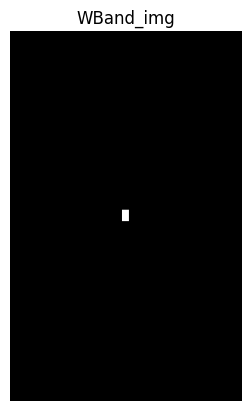

In [4]:
BWBand_img = grayscale_transformation.BWBand(7,11)
plt.imshow(BWBand_img,cmap='gray')
plt.axis('off')
plt.title('WBand_img')
plt.show()

# 2300350128 叶西佳

### 灰度级数量变换

In [5]:
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img

In [6]:
img = cv2.imread('/home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/2.jpg')  # 替换成你的图片路径
grayscale_transformation.rgb_img = img
gray_img = grayscale_transformation.rgb_to_gray()

In [7]:
grayscale_transformation.image = gray_img

In [8]:
reversed_img = grayscale_transformation.reverse()

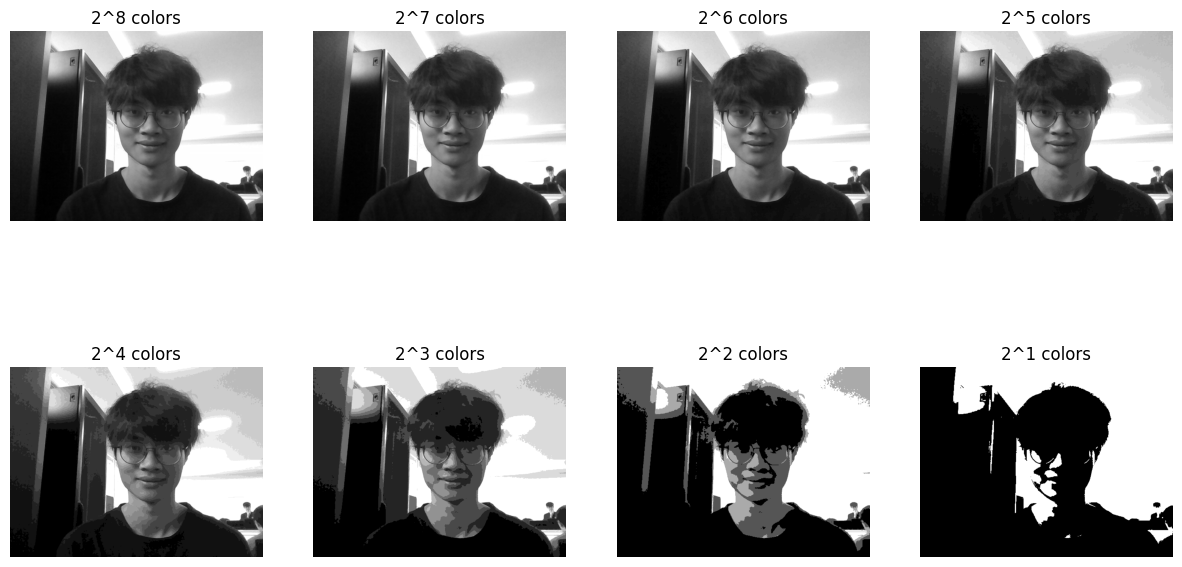

In [9]:
gray_layer_imgs = grayscale_transformation.gray_layer_Transform([256,128,64,32,16,8,4,2])
nums = [256,128,64,32,16,8,4,2]
plt.figure(figsize=(15,8))
for index,gray_layer_img in enumerate(gray_layer_imgs):
    plt.subplot(2,4,index+1)
    plt.imshow(gray_layer_img,cmap='gray')
    plt.axis('off')
    plt.title(f'2^{8-index} colors')
plt.show()




# 2300350128 叶西佳

### 图像压缩

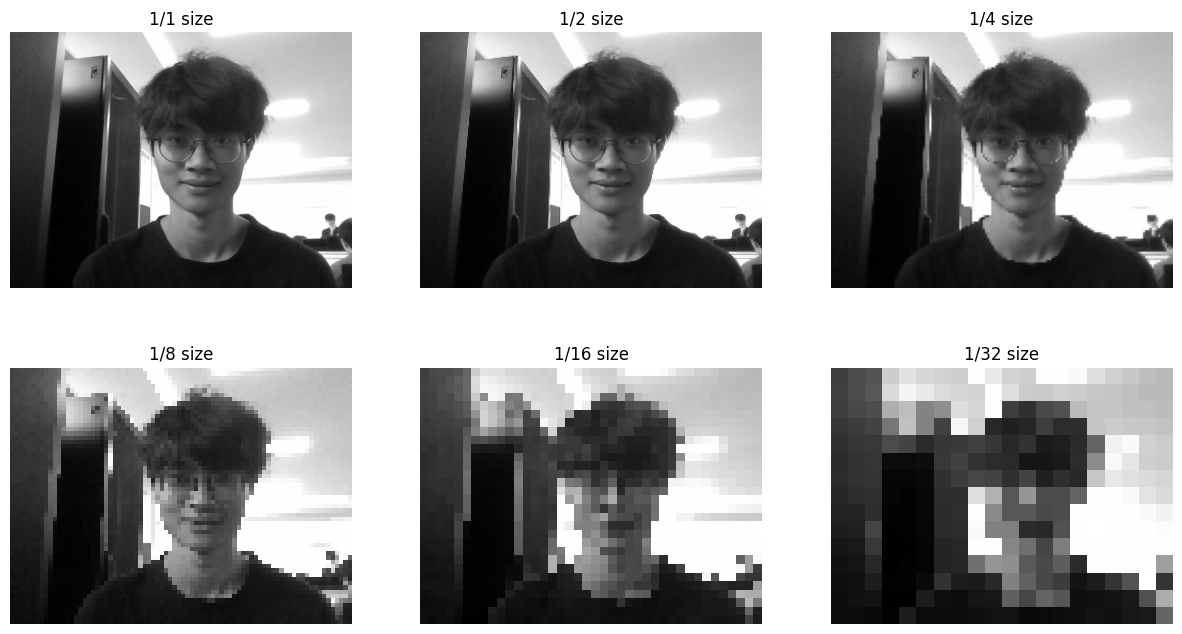

In [10]:
scales = [1,2,4,8,16,32]
gray_imgs = grayscale_transformation.spatial_transform(scales)

plt.figure(figsize=(15,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(gray_imgs[i], cmap='gray')
    plt.title(f'1/{scales[i]} size')
    plt.axis('off')
plt.show()

# 2300350128 叶西佳

### 绘制直方图

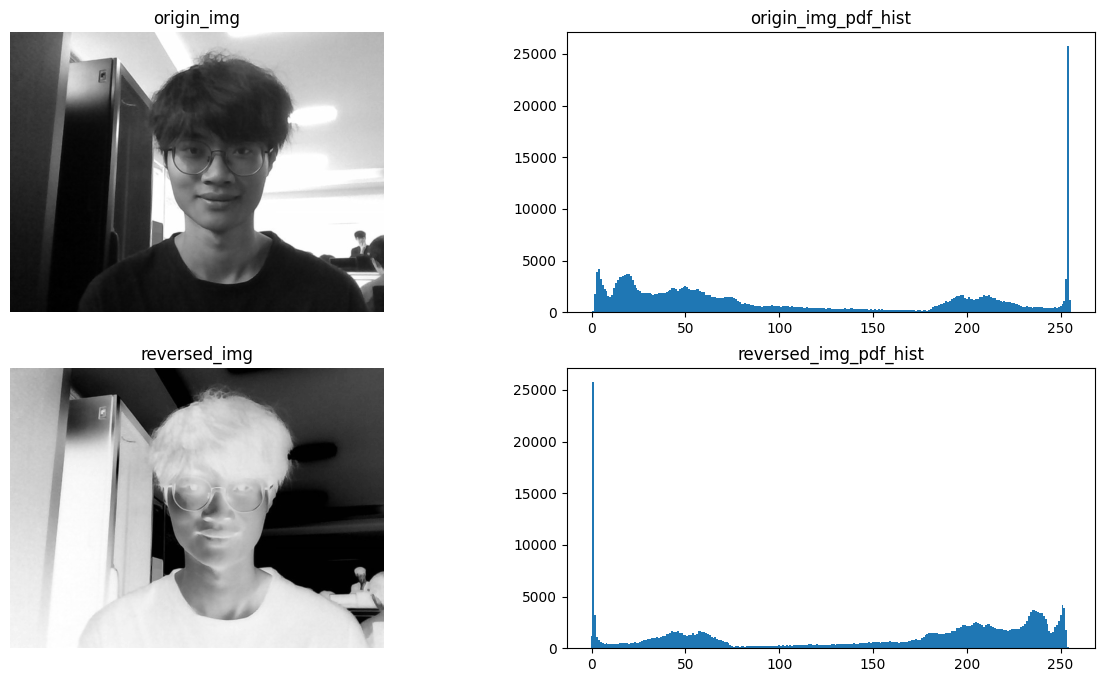

In [11]:
# 原图
plt.figure(figsize=(15,8))
plt.subplot(2,2,1)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')
pdf = grayscale_transformation.PDF(grayscale_transformation.image)

# 原图直方图

plt.subplot(2,2,2)
plt.bar(range(256),pdf,width=1)
plt.title('origin_img_pdf_hist')

# 反转图

plt.subplot(2,2,3)
plt.imshow(reversed_img,cmap='gray')
plt.title('reversed_img')
plt.axis('off')
pdf = grayscale_transformation.PDF(reversed_img)

# 反转直方图
plt.subplot(2,2,4)
plt.bar(range(256),pdf,width=1)
plt.title('reversed_img_pdf_hist')
plt.show()


# 2300350128 叶西佳

### 直方图均衡化

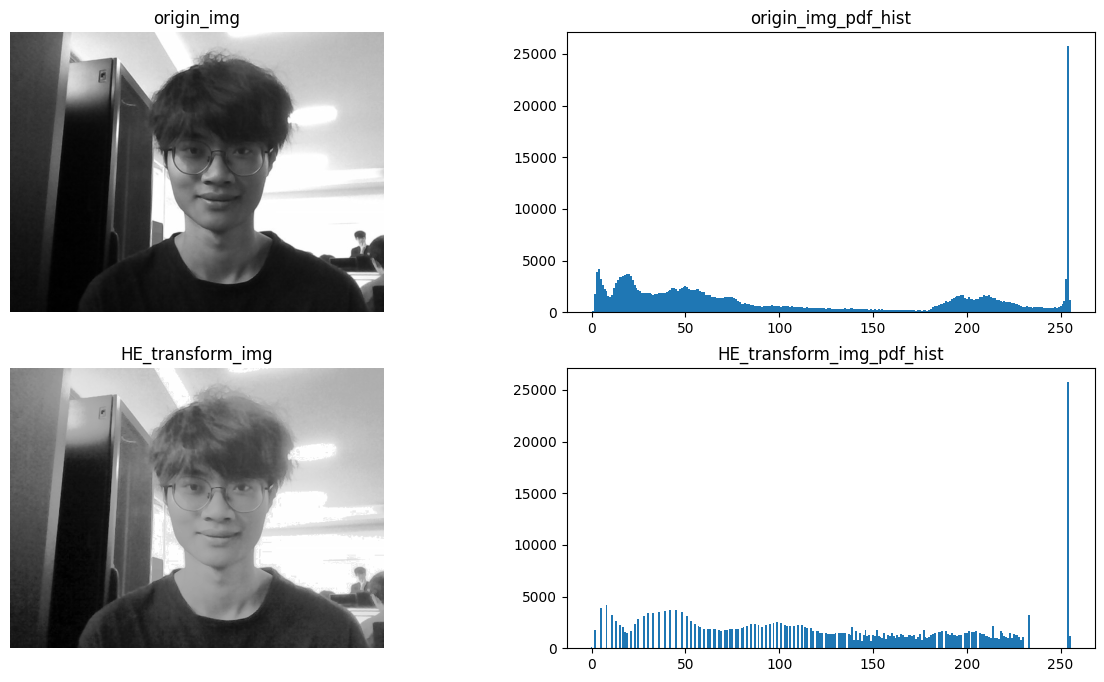

In [12]:
# 原图
plt.figure(figsize=(15,8))
plt.subplot(2,2,1)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')
pdf = grayscale_transformation.PDF(grayscale_transformation.image)

# 原图直方图

plt.subplot(2,2,2)
plt.bar(range(256),pdf,width=1)
plt.title('origin_img_pdf_hist')


# 均衡化后的图
histogram_equalization_img = grayscale_transformation.histogram_equalization()
plt.subplot(2,2,3)
plt.imshow(histogram_equalization_img,cmap='gray')
plt.axis('off')
plt.title('HE_transform_img')
pdf = grayscale_transformation.PDF(histogram_equalization_img)


# 均衡化后的直方图
plt.subplot(2,2,4)
plt.bar(range(256),pdf,width=1)
plt.title('HE_transform_img_pdf_hist')
plt.show()

# 2300350128 叶西佳

### gamma变换

In [13]:
gray_img = read_gray('/home/ubuntu/codebase/yexijia/github_project/DIP/Experiment_GUET/src/class_img/dark.jpg')
grayscale_transformation.image = gray_img

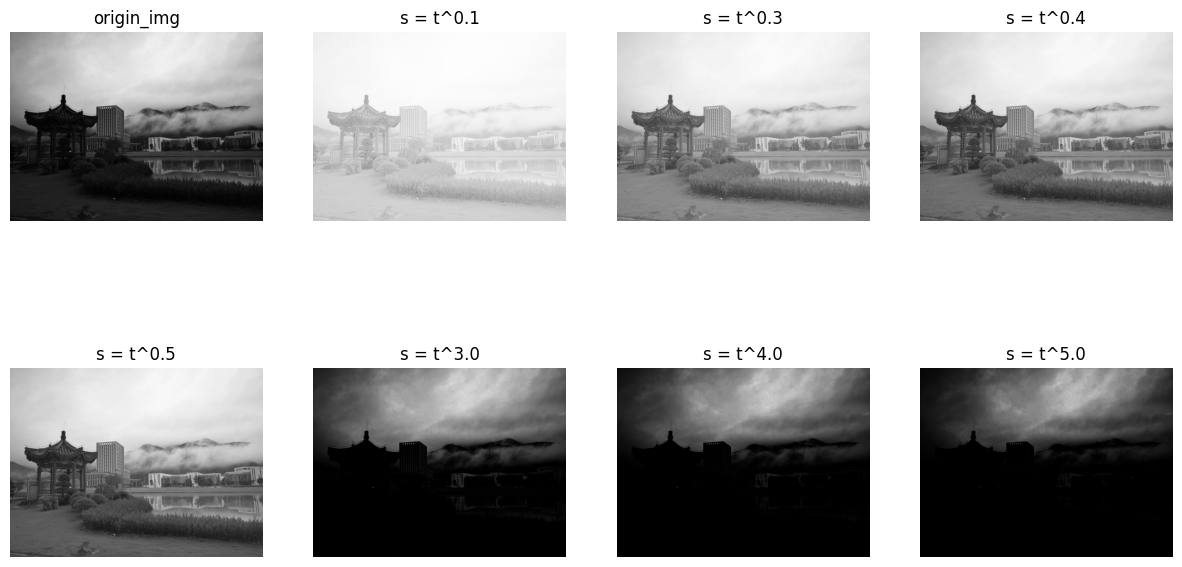

In [14]:
# 原图
plt.figure(figsize=(15,8))
plt.subplot(2,4,1)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')


# 伽马变换
for i,gamma in enumerate([0.1,0.3,0.4,0.5,3.0,4.0,5.0]):
    gamma_img = grayscale_transformation.gammaTransform(c = 1,gamma = gamma)
    plt.subplot(2,4,i+2)  
    plt.imshow(gamma_img,cmap='gray')
    plt.axis('off')
    plt.title(f's = t^{gamma}')
plt.show()

# 2300350128 叶西佳

### 对数变换

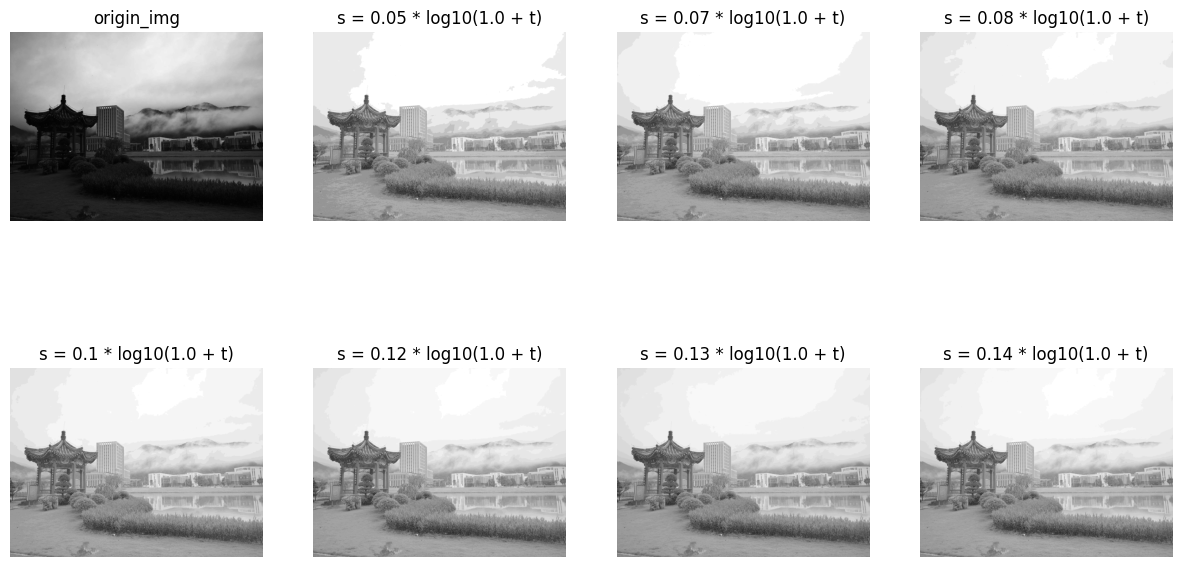

In [15]:
# 原图
plt.figure(figsize=(15,8))
plt.subplot(2,4,1)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')


# 对数变换
for i,times in enumerate([0.05,0.07,0.08,0.1,0.12,0.13,0.14]):
    log_img = grayscale_transformation.logTransform(times)
    plt.subplot(2,4,i+2)
    plt.imshow(log_img,cmap='gray')
    plt.axis('off')
    plt.title(f's = {times} * log10(1.0 + t)')
plt.show()

# 2300350128 叶西佳

### 查看直方图均衡化和gamma变换和对数变换的结果

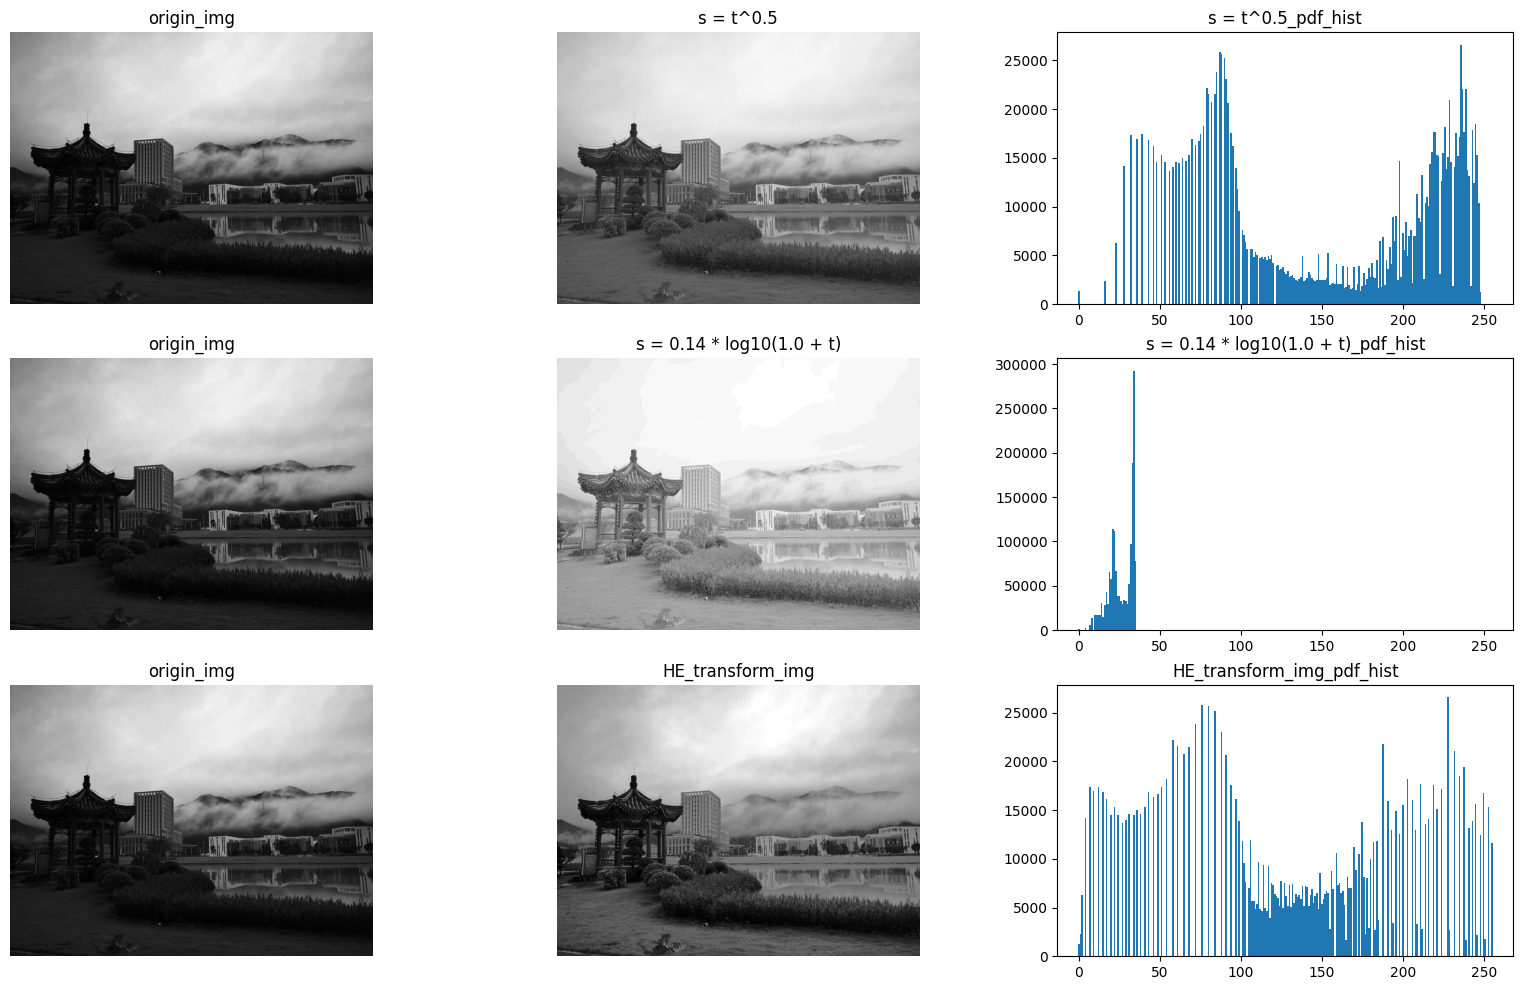

In [16]:
# 原图
plt.figure(figsize=(20,12))
plt.subplot(3,3,1)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')

# 伽马变换
gamma_img = grayscale_transformation.gammaTransform(c = 1,gamma = 0.5)
plt.subplot(3,3,2)  
plt.imshow(gamma_img,cmap='gray')
plt.axis('off')
plt.title(f's = t^0.5')

#直方图
pdf = grayscale_transformation.PDF(gamma_img)
plt.subplot(3,3,3)
plt.bar(range(256),pdf,width=1)
plt.title('s = t^0.5_pdf_hist')


# 原图
plt.subplot(3,3,4)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')

# 对数变换
log_img = grayscale_transformation.logTransform(0.14)
plt.subplot(3,3,5)
plt.imshow(log_img,cmap='gray')
plt.axis('off')
plt.title(f's = {0.14} * log10(1.0 + t)')

# 直方图
pdf = grayscale_transformation.PDF(log_img)
plt.subplot(3,3,6)
plt.bar(range(256),pdf,width=1)
plt.title(f's = {0.14} * log10(1.0 + t)_pdf_hist')



# 原图
plt.subplot(3,3,7)
plt.imshow(grayscale_transformation.image,cmap='gray')
plt.title('origin_img')
plt.axis('off')


# 均衡化后的图
histogram_equalization_img = grayscale_transformation.histogram_equalization()
plt.subplot(3,3,8)
plt.imshow(histogram_equalization_img,cmap='gray')
plt.axis('off')
plt.title('HE_transform_img')
pdf = grayscale_transformation.PDF(histogram_equalization_img)


# 均衡化后的直方图
plt.subplot(3,3,9)
plt.bar(range(256),pdf,width=1)
plt.title('HE_transform_img_pdf_hist')
plt.show()

# 2300350128 叶西佳